## <center> Понятие Корреляция. Коэффициент корреляции

In [1]:
import pandas as pd
import statistics

In [2]:
df = pd.read_csv('data/wine_cleared.csv')

>**Корреляция** — статистическая связь двух и более переменных. При изменении значения одной из переменных происходит закономерное изменение другой или других величин. 

Мерой связи величин, мерой корреляции является **коэффициент корреляции**. Он может принимать значение от -1 до +1.

**Отрицательная корреляция**, коэффициент корреляции < 0 говорит об обратной связи между переменными. При обратной связи увеличение одной из величин ведёт к закономерному уменьшению другой (других) величин. 

**Положительная корреляция**, коэффициент корреляции > 0 говорит о прямой связи между переменными. При прямой связи увеличение одной из величин ведёт к закономерному увеличению другой (других) величин. 

**Коэффициент корреляции = 0** говорит о том, что переменные независимы друг от друга, по крайней мере линейно, но это вовсе не значит, что между ними нет какой-то более сложной взаимосвязи. Это достаточно редкое явление, которое может встретиться на конкретном наборе данных.

>Понимание корреляции приводит нас к понятию **мультиколлинеарности** — такой сильной зависимости переменных друг от друга, что она затрудняет анализ и оценку будущей модели машинного обучения. 

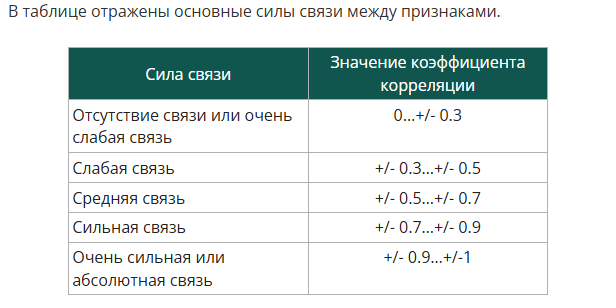

>Принято считать, что при коэффициенте корреляции +/-0,7 связь между признаками сильная и приводит к мультиколлинеарности.

Для расчёта коэффициента корреляции применим функцию [df.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) библиотеки pandas.
```python
data.corr()

In [ ]:
correlation = df['price'].corr(df['points'])

In [8]:
print(f"Величина коэффициента корреляции между ценой за бутылку и баллами за вино - {round(correlation,6)}")

Величина коэффициента корреляции между ценой за бутылку и баллами за вино - 0.402137


Результатом функции df.corr() является матрица корреляции. 

>**Матрица корреляции** — таблица, заголовками и строками которой являются названия признаков в датасете. На пересечении строк и столбцов находится значение коэффициента корреляции этих двух признаков.

Данная матрица имеет значение 1 по главной диагонали, так как единица означает корреляцию признака с самим собой. Матрица является **симметричной**. 

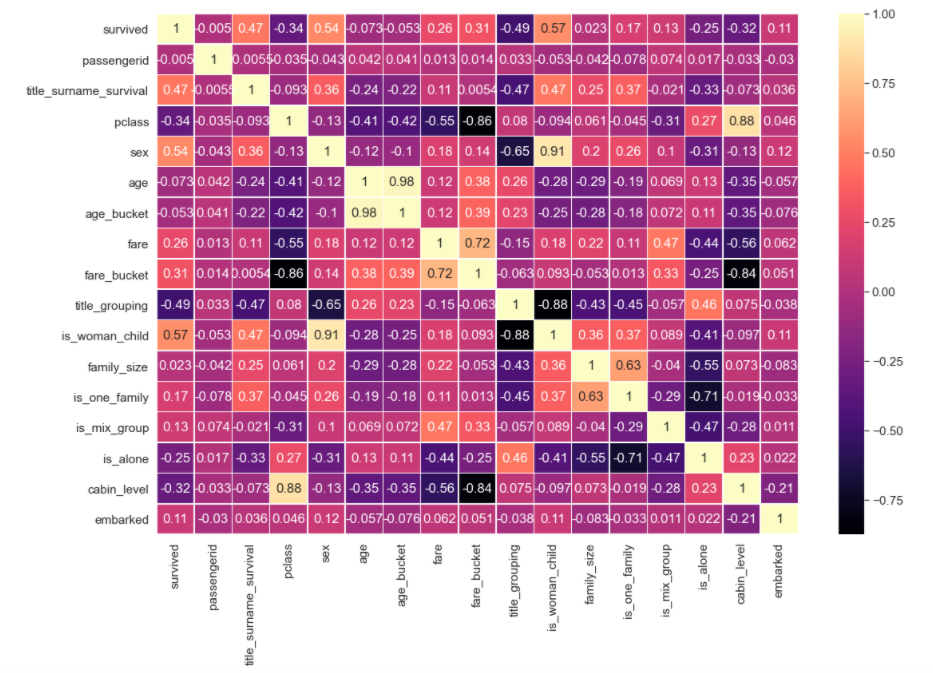

---

## <center> Типы корреляций. 

Аргумент ```method``` метода ```df.corr()``` указывает на название используемого метода расчёта корреляции: 
* 'pearson' — корреляция Пирсона, 
* 'kendall' — корреляция Кендалла, 
* 'spearman' — корреляция Спирмена. 

Каждый метод может быть применён для разных типов данных. Давайте разберёмся, чем отличаются эти методы и для каких типов данных применять каждый из них.

## <center>  Корреляция Пирсона

>**Коэффициент корреляции Пирсона** используется для вычисления линейной взаимосвязи между признаками.

Линейная взаимосвязь — вид связи между признаками, в котором изменение одного признака  всегда приводит к изменению другого признака  на величину, пропорциональную изменению , в соответствии с правилом:  (уравнение прямой), где  и  — некоторые коэффициенты.

#### <center> Hормальное распределение 

>Если признак является совокупностью очень редких событий, например аварии на дорогах, то распределение признака нормальным не будет.

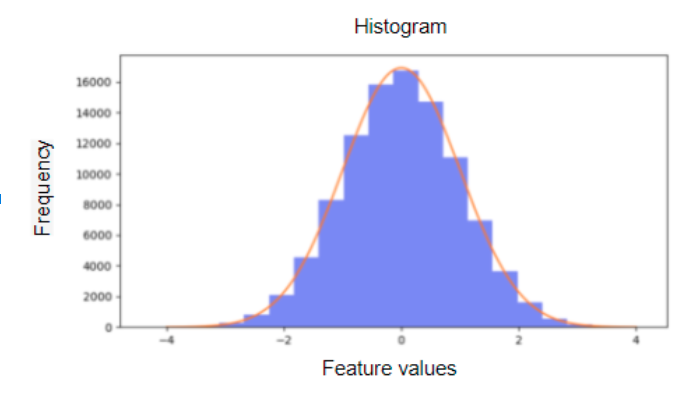
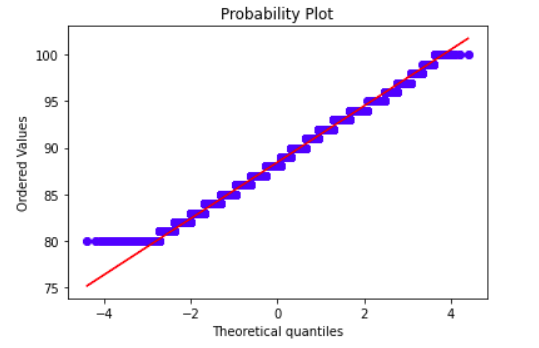

На гистограмме распределение должно напоминать колокол (левый график на рисунке), а q-q plot должен напоминать прямую линию (правый график на рисунке).

>Давайте проверим наши данные винных обзоров на нормальность, используя метод визуализации.

Для этого воспользуемся пакетом [stats](https://docs.scipy.org/doc/scipy/reference/stats.html#module-scipy.stats) статистических распределений и функций, а также знакомой нам библиотекой matplotlib для построения графиков.

Код для построения графиков:

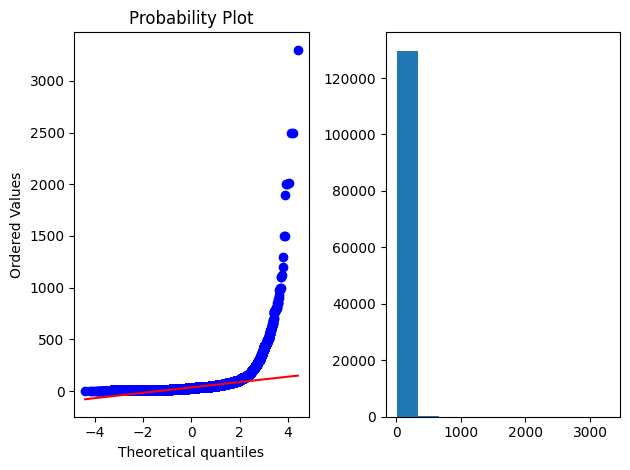

In [10]:
import matplotlib.pyplot as plt # библиотека визуализации
from scipy import stats # библиотека для расчетов

plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(df['price'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(df['price']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

Кажется, признак распределён ненормально, так как q-q plot имеет изогнутую линию, а гистограмма распределения совершенно не похожа на колокол.

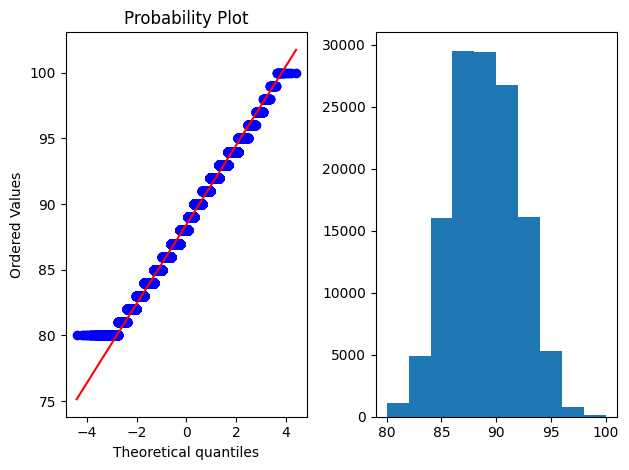

In [12]:
import matplotlib.pyplot as plt # библиотека визуализации
from scipy import stats # библиотека для расчетов

plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(df['points'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(df['points']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

* Корреляция между непрерывными признаками, которые имеют близкое к нормальному распределение, может быть рассчитана с использованием стандартной корреляции Пирсона. 
* Для категориальных данных используются методы ранговой корреляции, например Спирмена и Кендалла, которые будут изучены в следующем юните. 
* Для непрерывных переменных, имеющих большое количество выбросов или распределённых ненормально, могут использоваться методы по устранению выбросов и нормализации данных, которые будут изучены далее в курсе. Также могут быть использованы методы ранговой корреляции.